# Technical validation: SDLP and eye measures

One figure with four boxplots across the 10 driving modules. Each participant contributes one SDLP or mean event duration per module. All signals and module boundaries come from `processed_data/XDF`, resolved through `ImBrAid/config.json`.

- **Silab (SDLP):** sample standard deviation (`ddof=1`) of `LateralDistance`, in metres, at the recorded sampling rate.
- **Eyeball Video (BD):** recorded bilateral pupil areas and confidence labels, with the unchanged helper defaults.
- **Eye Tracking (EyesNotFound):** mean exported `Eye movement event duration` (ms) for `Eye movement type == "EyesNotFound"`, using only `Sensor == "Eye Tracker"` rows. Each event contributes once, identified by consecutive rows with the same event type and `Eye movement type index`. The exported duration includes a sampling interval beyond the first-to-last sample span and is used directly. This is a tracking-loss event measure, not physiological blink duration.
- **Driver Video (BD):** estimated eye-closure duration from bilateral eye aspect ratios (EAR), using six eyelid landmarks per eye. EAR uses the stored full-frame-normalized x/y coordinates: XDF does not contain image dimensions, so this is a normalized-coordinate EAR proxy, not a pixel-correct EAR. Failed face/eye tracking is excluded from detection.

Eyeball and Driver Video reuse the unchanged `helpers.Eyeball.blink.detect_blink_events()`. Thresholds are fractions of each eye's rolling-median baseline:

| Input | Close / open | Baseline (samples) | Bilateral tolerance (samples) | Merge gap (s) |
| --- | --- | --- | --- | --- |
| Eyeball | 0.25 / 0.40 | 30 | 3 | 0.06 |
| Driver EAR | 0.50 / 0.70 | 10 | 0 | 0 |

Eyeball retains `summarize_blinks_by_scenario()`. EyesNotFound uses complete exported events whose samples and immediately adjacent samples belong to the same driving module; events touching recording boundaries are excluded. Distinct exported event indices remain separate even when consecutive. No pupil threshold, event merging, 50-800 ms blink filter, or additional timestamp-gap filter is applied to EyesNotFound. Driver detection splits at tracking failures and module changes. It temporarily permits zero-duration candidates so that a single closed sample is retained. A candidate is accepted only when the nearest preceding and following clearly open samples both show valid, bilateral opening (`ratio > 0.70`) in the same module. Intermediate transition samples are allowed within the same valid tracking segment. Its onset and offset are estimated at the midpoints between the bounding open samples and the first/last closed samples. The estimated duration must then be 0.05-0.80 s; module means use these estimates directly. The first-to-last closed-sample span and the bounding open-sample span are retained as sampling bounds in the event table returned by `driver_closure_events()`.

Driver samples are approximately 0.2 s apart: one closed sample has an estimated duration of about 200 ms, with sampling bounds of about 0-400 ms under the detector's state assumptions. These are not confidence intervals or precise physiological blink durations, and the 50 ms lower limit does not imply 50 ms resolution. Signals are not resampled. These modality-specific parameters are provisional and have not been validated against manual blink annotations.

As in `summarize_study()`, event means for modules shorter than 240 s are missing; no accepted events also gives a missing mean, not zero. Boxplot labels report the available participant count, and outliers remain visible.

XDF clock correction and dejittering are enabled for the original SILAB stream. Appended streams already use the recorder clock and retain their exact timestamps under these options. The helper's `real_time` is an arbitrary datetime representation of relative LSL seconds, not a calendar timestamp. No CSVs, images, or other files are exported. Sharing a detection function does not establish equivalent blink accuracy across modalities.

In [1]:
import sys
from pathlib import Path

sys.dont_write_bytecode = True
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyxdf

PROJECT_ROOT = next(
    p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (p / 'helpers/project_config.py').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from helpers.project_config import load_project_config
from helpers.Eyeball import blink

CONFIG = load_project_config(PROJECT_ROOT / 'ImBrAid/config.json')
XDF_ROOT = CONFIG.path('paths', 'publication_root') / 'XDF'
SCENARIO_IDS = list(blink.SCENARIO_IDS)
MODULES = {scenario: module for module, scenario in enumerate(SCENARIO_IDS, start=1)}

DRIVER_PARAMS = {'close_th': 0.50, 'open_th': 0.70, 'baseline_win': 10,
                 'sync_tolerance': 0, 'merge_gap': 0.0}

# Points go around each eye: outer/inner corner, two upper, opposite corner,
# and the corresponding two lower eyelid points (MediaPipe landmark indices).
EYE_POINTS = {'Left': (362, 385, 387, 263, 373, 380),
              'Right': (33, 160, 158, 133, 153, 144)}
REQUESTED = {
    'SILAB': ['ScenarioID', 'LateralDistance'],
    'Eyeball': ['Left_Pupil_Area', 'Right_Pupil_Area'],
    'Eyeball_labels': ['Left_Confidence', 'Right_Confidence'],
    'ET': ['Eye movement event duration', 'Eye movement type index'],
    'ET_labels': ['Sensor', 'Eye movement type'],
    'DriverVideo': ['face_detected'] + [
        f'face_{point:03d}_{axis}'
        for points in EYE_POINTS.values() for point in points for axis in ('x', 'y')
    ],
}


In [2]:
def read_recording(path):
    """Load only the required streams/channels into the common recorder clock."""
    selected = [s for s in pyxdf.resolve_streams(str(path)) if s['name'] in REQUESTED]
    names = [s['name'] for s in selected]
    if 'SILAB' not in names or len(names) != len(set(names)):
        raise ValueError(f'{path.name}: missing SILAB or duplicate requested streams')
    indices = {}

    def take_columns(values, timestamps, header, stream_id):
        name = header['info']['name'][0]
        if stream_id not in indices:
            labels = [c['label'][0] for c in
                      header['info']['desc'][0]['channels'][0]['channel']]
            indices[stream_id] = [labels.index(c) for c in REQUESTED[name]]
        return np.asarray(values)[:, indices[stream_id]].copy(), timestamps, header

    streams, _ = pyxdf.load_xdf(
        str(path), select_streams=[s['stream_id'] for s in selected],
        on_chunk=take_columns, synchronize_clocks=True, dejitter_timestamps=True,
        verbose=False,
    )
    frames = {}
    for stream in streams:
        name = stream['info']['name'][0]
        times = np.asarray(stream['time_stamps'], dtype=float)
        values = np.asarray(stream['time_series'])
        if not len(times):
            continue
        if not np.isfinite(times).all():
            raise ValueError(f'{path.name}: nonfinite timestamps in {name}')
        frame = pd.DataFrame(values, columns=REQUESTED[name])
        frame.insert(0, 'lsl_time_s', times)
        frames[name] = frame.sort_values('lsl_time_s', kind='stable').reset_index(drop=True)
    if 'SILAB' not in frames:
        raise ValueError(f'{path.name}: empty SILAB stream')
    frames['SILAB']['ScenarioID'] = np.floor(frames['SILAB']['ScenarioID'])
    return frames


def with_labels(frames, name):
    if name not in frames:
        return None
    numeric, labels = frames[name], frames[name + '_labels']
    if not np.array_equal(numeric['lsl_time_s'], labels['lsl_time_s']):
        raise ValueError(f'{name}: numeric and label timestamps do not match')
    return pd.concat([numeric, labels.drop(columns='lsl_time_s')], axis=1)


def eyeball_input(frames):
    return with_labels(frames, 'Eyeball')


def et_input(frames):
    et = with_labels(frames, 'ET')
    if et is None:
        return None
    return et.loc[et['Sensor'].eq('Eye Tracker')].reset_index(drop=True)


def driver_input(frames):
    if 'DriverVideo' not in frames:
        return None
    driver = frames['DriverVideo']
    pupil = driver[['lsl_time_s']].copy()
    valid = driver['face_detected'].eq(1).to_numpy()
    for side, points in EYE_POINTS.items():
        xy = driver[[f'face_{point:03d}_{axis}'
                     for point in points for axis in ('x', 'y')]].to_numpy(float).reshape(-1, 6, 2)
        width = np.linalg.norm(xy[:, 0] - xy[:, 3], axis=1)
        height = (np.linalg.norm(xy[:, 1] - xy[:, 5], axis=1)
                  + np.linalg.norm(xy[:, 2] - xy[:, 4], axis=1))
        eye_valid = np.isfinite(xy).all(axis=(1, 2)) & (width > 0)
        ear = np.divide(height, 2 * width, out=np.full(len(driver), np.nan), where=eye_valid)
        # The helper treats missing area as closure; zero EAR is complete closure.
        pupil[f'{side}_Pupil_Area'] = np.where(ear > 0, ear, np.nan)
        valid &= eye_valid
    pupil['tracking_valid'] = valid
    return pupil


In [3]:
def driver_closure_events(pupil):
    """Estimate bounded Driver eye closures; all durations and bounds are seconds."""
    rows = []
    if not pupil['real_time'].is_monotonic_increasing or pupil['real_time'].duplicated().any():
        raise ValueError('Driver Video timestamps must be strictly increasing')
    valid = pupil['tracking_valid'] & pupil['ScenarioID'].isin(SCENARIO_IDS)
    runs = (valid.ne(valid.shift())
            | pupil['ScenarioID'].ne(pupil['ScenarioID'].shift())).cumsum()
    for _, part in pupil.loc[valid].groupby(runs[valid], sort=False):
        # Zero is allowed only for candidates; final estimates are filtered below.
        detected, candidates, _ = blink.detect_blink_events(
            part, **DRIVER_PARAMS, min_dur=0.0
        )
        sizes = detected[['Left_Pupil_Area', 'Right_Pupil_Area']]
        sizes = sizes.where(sizes > 0)
        baseline = sizes.rolling(DRIVER_PARAMS['baseline_win'], min_periods=10).median().ffill().bfill()
        opened = (sizes.div(baseline) > DRIVER_PARAMS['open_th']).all(axis=1).to_numpy()
        times = detected['real_time'].to_numpy()
        open_indices = np.flatnonzero(opened)
        for start, end, _ in candidates:
            first, last = np.searchsorted(times, [start.to_datetime64(), end.to_datetime64()])
            before = np.searchsorted(open_indices, first) - 1
            after = np.searchsorted(open_indices, last, side='right')
            if before < 0 or after == len(open_indices):
                continue
            # Allow transition samples between definite closure and definite opening.
            left_open, right_open = open_indices[before], open_indices[after]
            lower_s = float((times[last] - times[first]) / np.timedelta64(1, 's'))
            upper_s = float((times[right_open] - times[left_open]) / np.timedelta64(1, 's'))
            duration_s = (lower_s + upper_s) / 2
            if blink.MIN_EVENT_S <= duration_s <= blink.MAX_EVENT_S:
                rows.append({'ScenarioID': int(detected['ScenarioID'].iloc[first]),
                             'duration_s': duration_s, 'lower_s': lower_s, 'upper_s': upper_s})
    return pd.DataFrame(rows, columns=['ScenarioID', 'duration_s', 'lower_s', 'upper_s'])


def eyesnotfound_events(et):
    """Count each complete exported EyesNotFound event once, without blink filtering."""
    et = et.reset_index(drop=True).copy()
    et['row'] = np.arange(len(et))
    runs = (et['Eye movement type'].ne(et['Eye movement type'].shift())
            | et['Eye movement type index'].ne(et['Eye movement type index'].shift())).cumsum()
    candidate = et.loc[et['Eye movement type'].eq('EyesNotFound')]
    grouped = candidate.groupby(runs.loc[candidate.index], sort=False)
    events = grouped.agg(
        event_index=('Eye movement type index', 'first'),
        duration_ms=('Eye movement event duration', 'first'),
        duration_values=('Eye movement event duration', lambda x: x.nunique(dropna=False)),
        ScenarioID=('ScenarioID', 'first'),
        scenario_values=('ScenarioID', lambda x: x.nunique(dropna=False)),
        first=('row', 'min'), last=('row', 'max'),
    )
    if not events['duration_values'].eq(1).all():
        raise ValueError('EyesNotFound duration changes within an exported event')
    if events['event_index'].isna().any() or events['event_index'].duplicated().any():
        raise ValueError('EyesNotFound event index is missing or reused in separate runs')
    if events.empty:
        return pd.DataFrame(columns=['ScenarioID', 'duration_s'])
    scenario = et['ScenarioID'].to_numpy()
    before = np.maximum(events['first'].to_numpy() - 1, 0)
    after = np.minimum(events['last'].to_numpy() + 1, len(et) - 1)
    complete = (events['first'].gt(0) & events['last'].lt(len(et) - 1)
                & events['scenario_values'].eq(1) & events['ScenarioID'].isin(SCENARIO_IDS)
                & (scenario[before] == events['ScenarioID'].to_numpy())
                & (scenario[after] == events['ScenarioID'].to_numpy()))
    valid = complete & np.isfinite(events['duration_ms']) & events['duration_ms'].gt(0)
    result = events.loc[valid, ['ScenarioID', 'duration_ms']].rename(
        columns={'duration_ms': 'duration_s'}
    )
    result['duration_s'] /= 1000
    return result.reset_index(drop=True)


def mean_event_duration(pupil, silab):
    """Return one mean (ms) per module using the modality's duration estimator."""
    empty = pd.Series(np.nan, index=SCENARIO_IDS, dtype=float)
    if pupil is None or pupil.empty:
        return empty
    pupil = pupil.copy()
    silab_times = silab['lsl_time_s'].to_numpy()
    times = pupil['lsl_time_s'].to_numpy()
    previous = np.searchsorted(silab_times, times, side='right') - 1
    covered = (previous >= 0) & (times <= silab_times[-1])
    scenario = np.full(len(pupil), np.nan)
    scenario[covered] = silab['ScenarioID'].to_numpy()[previous[covered]]
    pupil['ScenarioID'] = scenario
    # A synthetic datetime origin adapts relative recorder-clock seconds to the helper.
    pupil['real_time'] = pd.Timestamp('2000-01-01') + pd.to_timedelta(times - silab_times[0], unit='s')

    if 'tracking_valid' in pupil:
        events = driver_closure_events(pupil)
    elif 'Eye movement type' in pupil:
        events = eyesnotfound_events(pupil)
    else:
        events = None
    if events is not None:
        means = events.groupby('ScenarioID')['duration_s'].mean().astype(float)
        spans = pupil.loc[pupil['ScenarioID'].isin(SCENARIO_IDS)].groupby('ScenarioID')['real_time'].agg(['min', 'max'])
        duration_s = (spans['max'] - spans['min']).dt.total_seconds()
        return (means.reindex(SCENARIO_IDS).where(
            duration_s.reindex(SCENARIO_IDS) >= blink.MIN_SCENARIO_DURATION_S
        ) * 1000)

    pupil = pupil.loc[pupil['ScenarioID'].isin(SCENARIO_IDS)].reset_index(drop=True)
    if pupil.empty:
        return empty
    pupil, _, mask = blink.detect_blink_events(pupil)
    pupil['blink'] = mask
    summary = blink.summarize_blinks_by_scenario(pupil).set_index('ScenarioID')
    means = summary['Blink_Average_Length_s'].where(
        summary['Scenario_Duration_s'] >= blink.MIN_SCENARIO_DURATION_S
    ) * 1000
    return means.reindex(SCENARIO_IDS)


In [4]:
xdf_paths = sorted(XDF_ROOT.glob('*_synchronized.xdf'))
if not xdf_paths:
    raise FileNotFoundError(f'No synchronized XDF files in {XDF_ROOT}')
participants = [path.stem.removesuffix('_synchronized').rsplit('_', 1)[0] for path in xdf_paths]
if len(participants) != len(set(participants)):
    raise ValueError('Multiple recordings per participant: specify visit aggregation before plotting')

records = []
missing_streams = []
for index, (path, participant) in enumerate(zip(xdf_paths, participants), start=1):
    frames = read_recording(path)
    silab = frames['SILAB']
    sdlp = (silab.assign(LateralDistance=silab['LateralDistance'].where(
                np.isfinite(silab['LateralDistance'])))
            .groupby('ScenarioID')['LateralDistance'].std(ddof=1).reindex(SCENARIO_IDS))
    row = pd.DataFrame({'Silab (SDLP)': sdlp})
    for label, stream, adapter in [
        ('Eyeball Video (BD)', 'Eyeball', eyeball_input),
        ('Eye Tracking (EyesNotFound)', 'ET', et_input),
        ('Driver Video (BD)', 'DriverVideo', driver_input),
    ]:
        if stream not in frames:
            missing_streams.append(f'{participant}: {stream}')
        row[label] = mean_event_duration(adapter(frames), silab)
    row.index.name = 'ScenarioID'
    row = row.reset_index()
    row.insert(0, 'Participant', participant)
    row.insert(1, 'Module', row['ScenarioID'].map(MODULES))
    records.append(row)
    del frames
    print(f'{index}/{len(xdf_paths)}: {participant}', flush=True)

metrics = pd.concat(records, ignore_index=True)
print(f'{len(participants)} participants; {len(metrics)} participant-module rows.')
if missing_streams:
    print('Unavailable streams (kept as missing): ' + '; '.join(missing_streams))


1/43: A7G5SM
2/43: ABVLGQ
3/43: B9NYQ8
4/43: CRVWF9
5/43: CRYSEP
6/43: CU6DM4
7/43: DUJL2L
8/43: E4MKXT
9/43: EASFXM
10/43: FEDZAG
11/43: FGJK2B
12/43: FLZWD8
13/43: G93LYM
14/43: GLRNU9
15/43: HH5RBX
16/43: HKJPM3
17/43: HNWSPB
18/43: JVC62S
19/43: LGJEFY
20/43: LKK2WT
21/43: MUHKQF
22/43: N37VFK
23/43: N7C4A6
24/43: NJN65T
25/43: PJ52F4
26/43: Q5ZPCB
27/43: R595WP
28/43: R8YB77
29/43: RYE8J9
30/43: RZKLE8
31/43: S99GF9
32/43: SHUPW7
33/43: SPKHNL
34/43: TXRE5B
35/43: U83GH3
36/43: UY6WA8
37/43: V3SLBM
38/43: VUT5TP
39/43: W3MTYZ
40/43: XJF6R9
41/43: YHYKDQ
42/43: Z8HDMS
43/43: ZQTXLD
43 participants; 430 participant-module rows.
Unavailable streams (kept as missing): EASFXM: Eyeball; FEDZAG: Eyeball; G93LYM: Eyeball; G93LYM: ET; G93LYM: DriverVideo; HKJPM3: Eyeball; HKJPM3: ET; HKJPM3: DriverVideo; JVC62S: Eyeball; JVC62S: ET; JVC62S: DriverVideo; N37VFK: Eyeball; N37VFK: ET; N37VFK: DriverVideo; R8YB77: DriverVideo; RZKLE8: Eyeball; SHUPW7: Eyeball; V3SLBM: Eyeball; V3SLBM: ET; V3SL

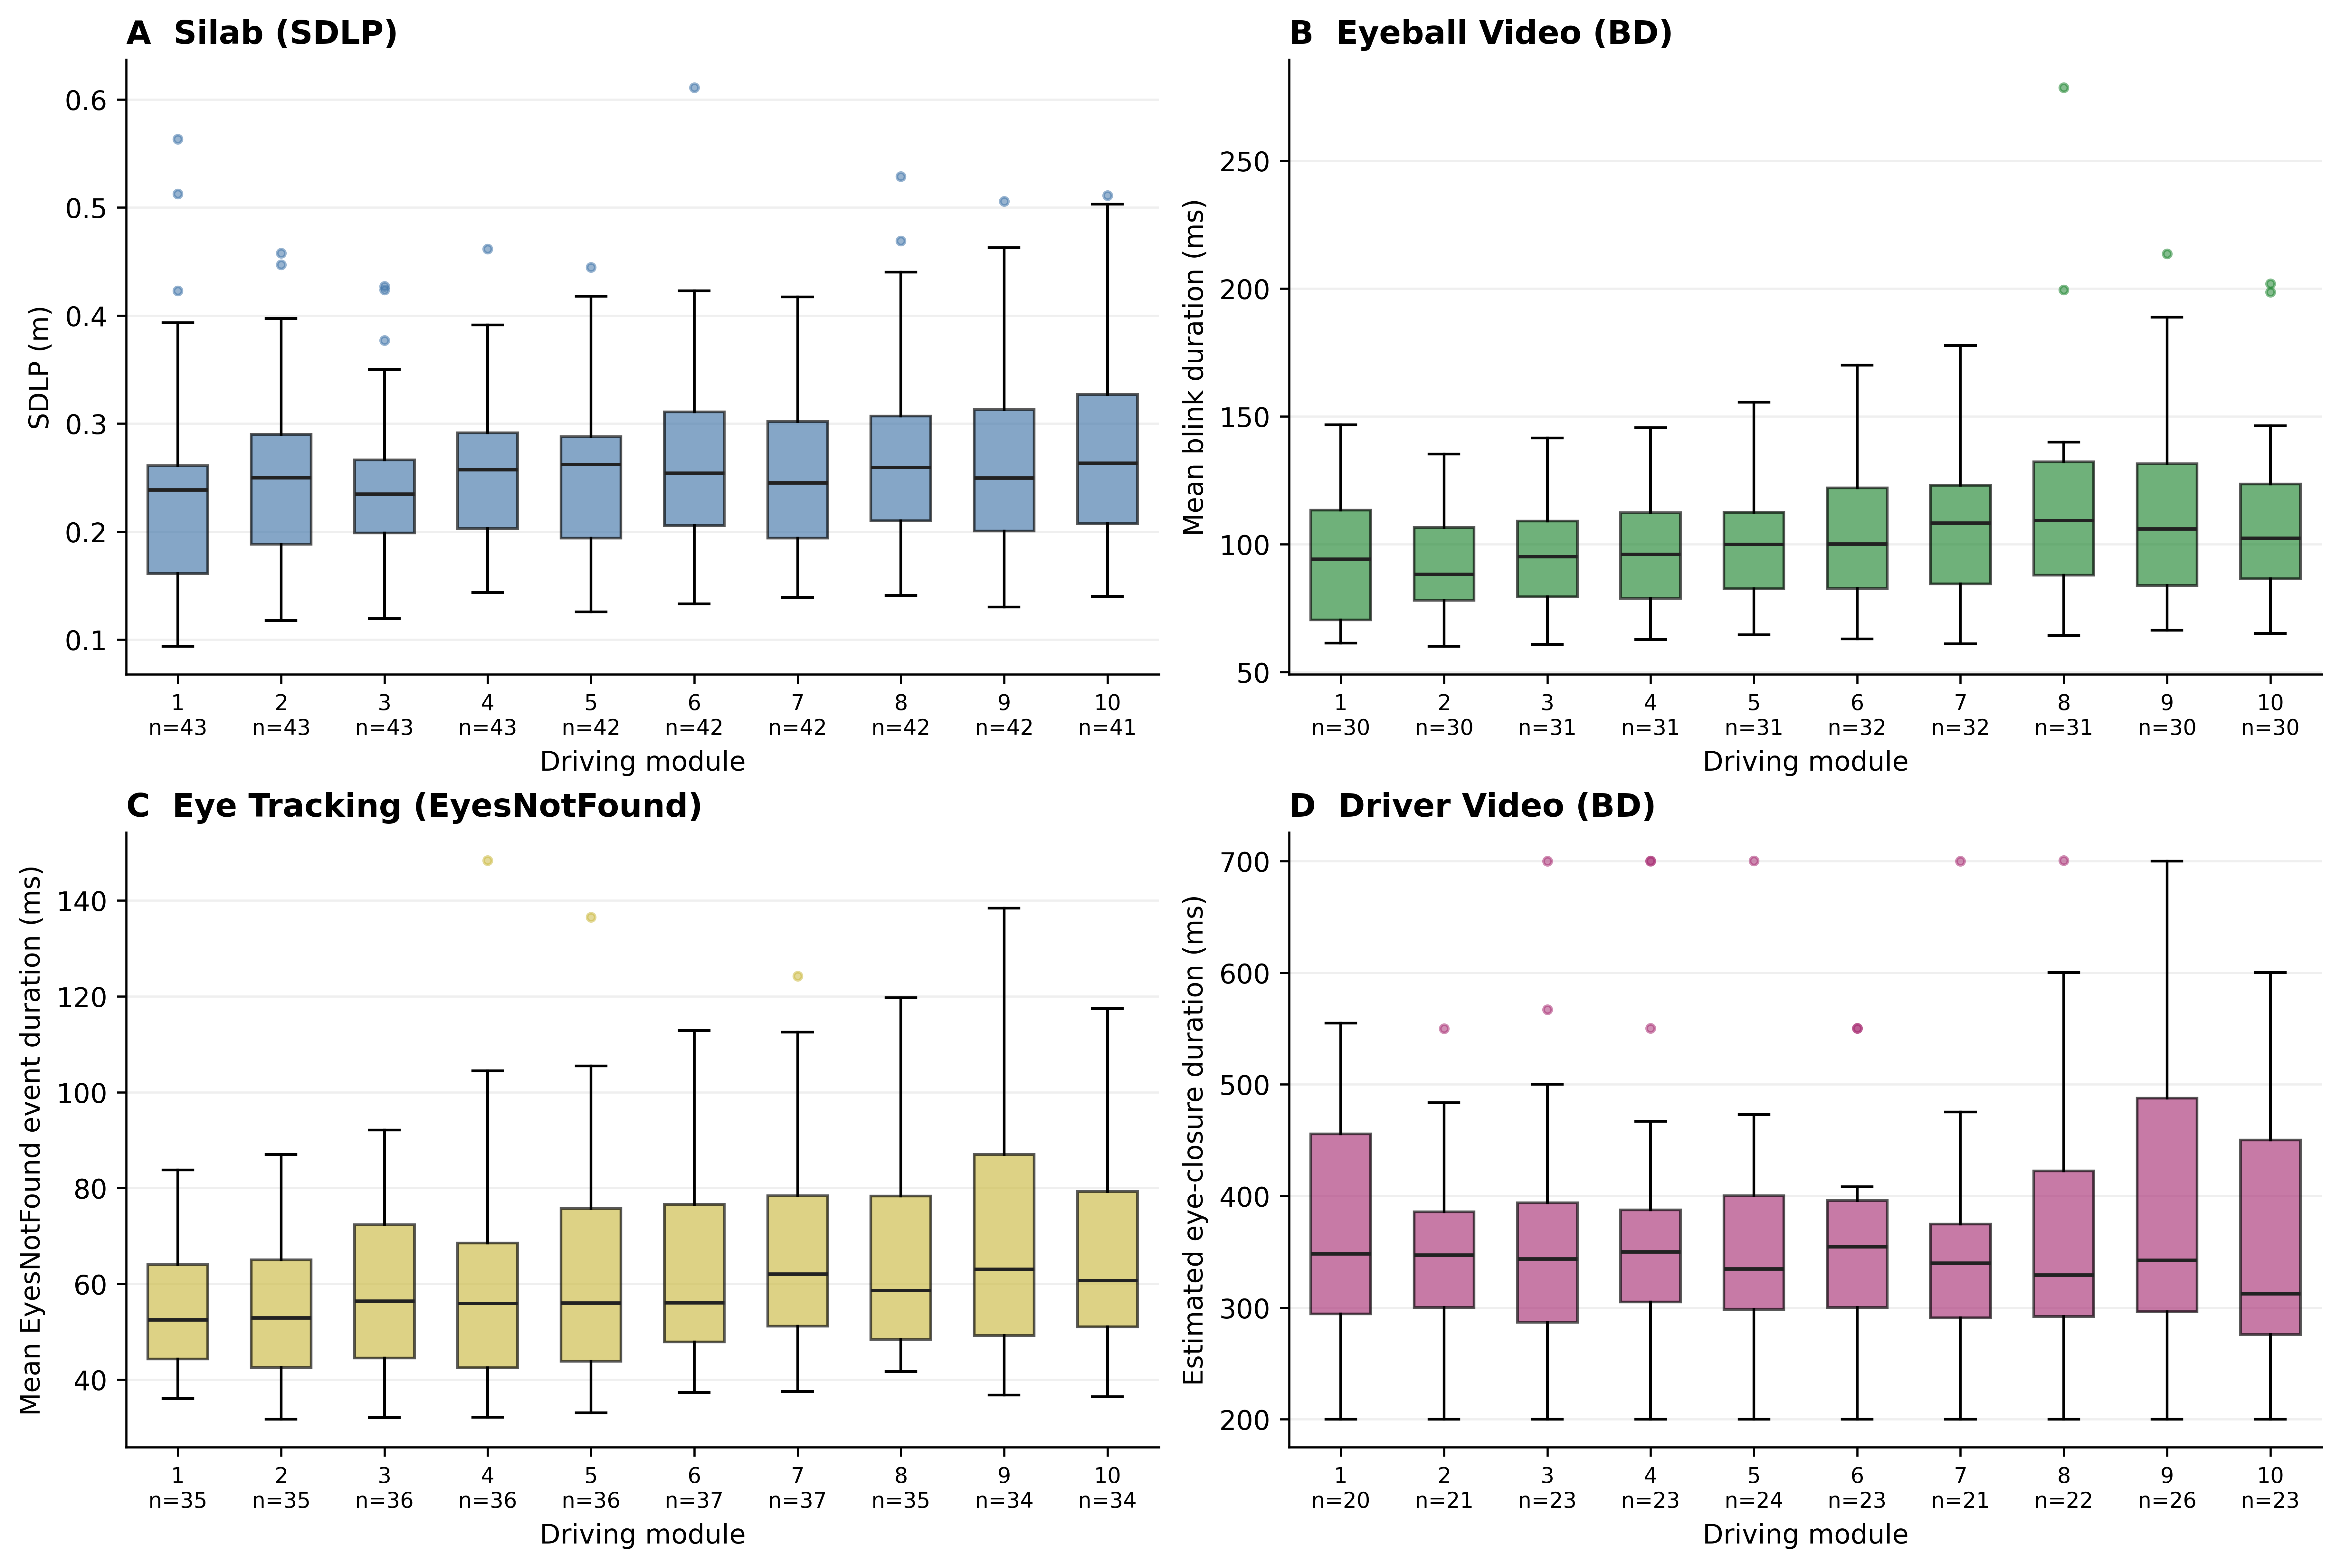

In [5]:
panels = [
    ('Silab (SDLP)', 'SDLP (m)', '#4477AA'),
    ('Eyeball Video (BD)', 'Mean blink duration (ms)', '#228833'),
    ('Eye Tracking (EyesNotFound)', 'Mean EyesNotFound event duration (ms)', '#CCBB44'),
    ('Driver Video (BD)', 'Estimated eye-closure duration (ms)', '#AA3377'),
]
with plt.rc_context({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained', dpi=600)
    for letter, ax, (metric, ylabel, color) in zip('ABCD', axes.flat, panels):
        groups = [metrics.loc[metrics['Module'].eq(module), metric].dropna().to_numpy()
                  for module in range(1, 11)]
        ax.boxplot(groups, positions=range(1, 11), widths=0.58, patch_artist=True,
                   showfliers=True, whis=1.5,
                   boxprops={'facecolor': color, 'alpha': 0.65},
                   medianprops={'color': '#222222', 'linewidth': 1.3},
                   flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.55,
                               'markerfacecolor': color, 'markeredgecolor': color})
        ax.set_title(f'{letter}  {metric}', loc='left', fontweight='bold')
        ax.set(xlabel='Driving module', ylabel=ylabel)
        ax.set_xticks(range(1, 11), [f'{module}\nn={len(values)}'
                                   for module, values in enumerate(groups, start=1)])
        ax.tick_params(axis='x', labelsize=8)
        ax.set_axisbelow(True)
        ax.grid(axis='y', alpha=0.2)
        if not any(len(values) for values in groups):
            ax.text(0.5, 0.5, 'No available values', ha='center', transform=ax.transAxes)
    plt.show()


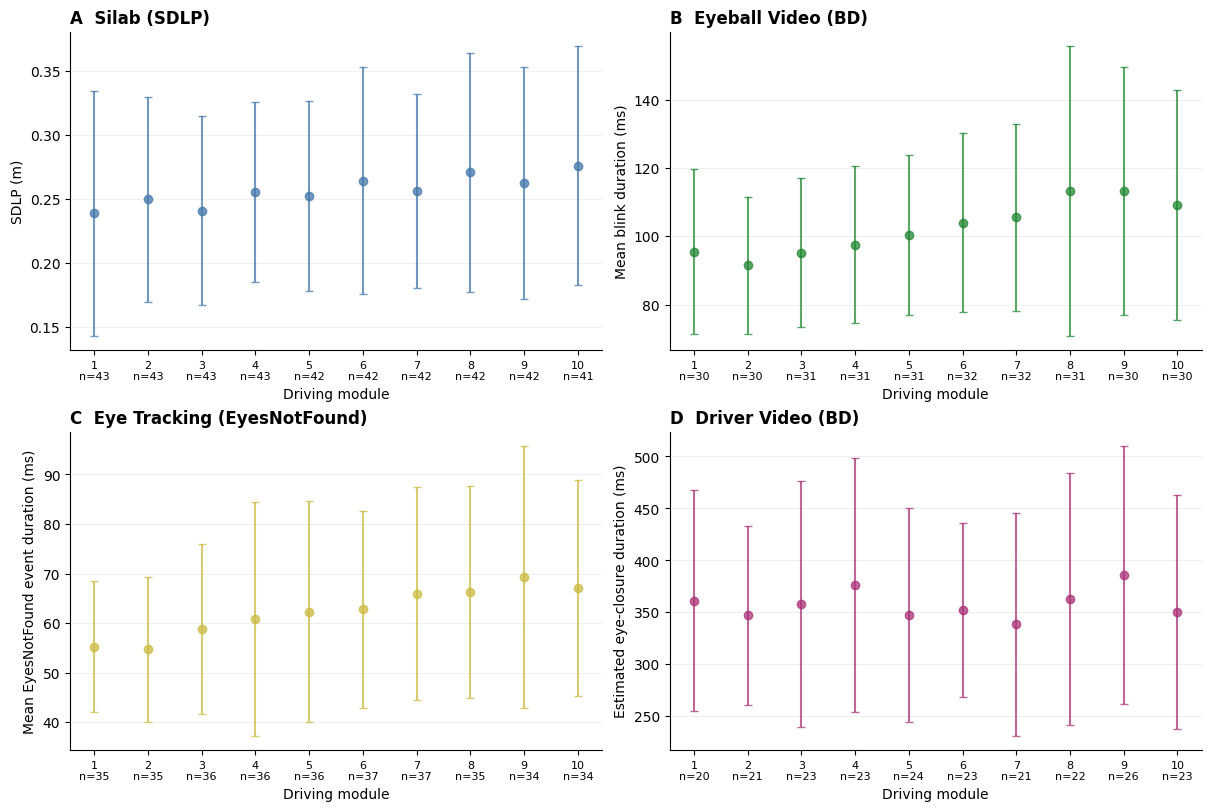

In [6]:
panels = [
    ('Silab (SDLP)', 'SDLP (m)', '#4477AA'),
    ('Eyeball Video (BD)', 'Mean blink duration (ms)', '#228833'),
    ('Eye Tracking (EyesNotFound)', 'Mean EyesNotFound event duration (ms)', '#CCBB44'),
    ('Driver Video (BD)', 'Estimated eye-closure duration (ms)', '#AA3377'),
]
with plt.rc_context({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
    for letter, ax, (metric, ylabel, color) in zip('ABCD', axes.flat, panels):
        groups = [metrics.loc[metrics['Module'].eq(module), metric].dropna().to_numpy()
                  for module in range(1, 11)]
        # ax.boxplot(groups, positions=range(1, 11), widths=0.58, patch_artist=True,
                #    showfliers=True, whis=1.5,
                #    boxprops={'facecolor': color, 'alpha': 0.65},
                #    medianprops={'color': '#222222', 'linewidth': 1.3},
                #    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.55,
                            #    'markerfacecolor': color, 'markeredgecolor': color})
        ax.errorbar(range(1, 11), [np.nanmean(values) for values in groups],
                    yerr=[np.nanstd(values) for values in groups], fmt='o', color=color,
                    ecolor=color, elinewidth=1.5, capsize=3, markersize=6, alpha=0.75)
        ax.set_title(f'{letter}  {metric}', loc='left', fontweight='bold')
        ax.set(xlabel='Driving module', ylabel=ylabel)
        ax.set_xticks(range(1, 11), [f'{module}\nn={len(values)}'
                                   for module, values in enumerate(groups, start=1)])
        ax.tick_params(axis='x', labelsize=8)
        ax.set_axisbelow(True)
        ax.grid(axis='y', alpha=0.2)
        if not any(len(values) for values in groups):
            ax.text(0.5, 0.5, 'No available values', ha='center', transform=ax.transAxes)
    plt.show()


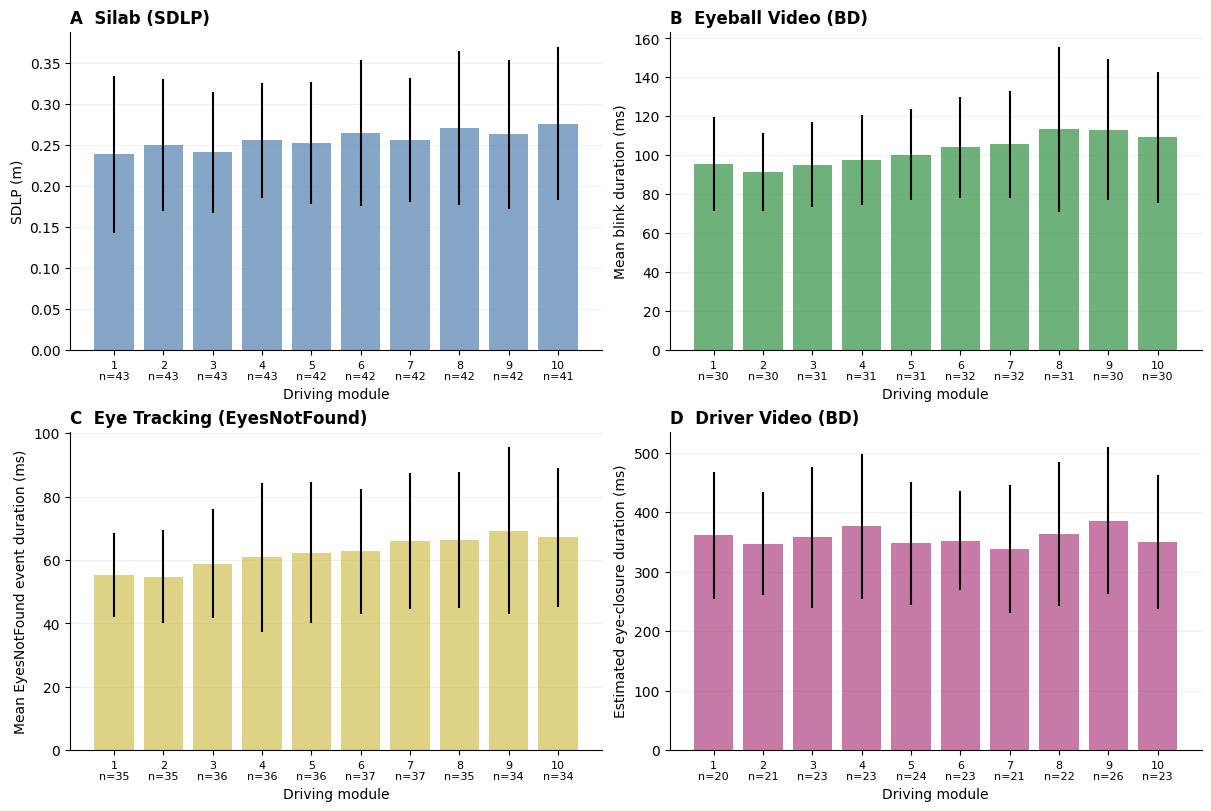

In [7]:
panels = [
    ('Silab (SDLP)', 'SDLP (m)', '#4477AA'),
    ('Eyeball Video (BD)', 'Mean blink duration (ms)', '#228833'),
    ('Eye Tracking (EyesNotFound)', 'Mean EyesNotFound event duration (ms)', '#CCBB44'),
    ('Driver Video (BD)', 'Estimated eye-closure duration (ms)', '#AA3377'),
]
with plt.rc_context({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False}):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout='constrained')
    for letter, ax, (metric, ylabel, color) in zip('ABCD', axes.flat, panels):
        groups = [metrics.loc[metrics['Module'].eq(module), metric].dropna().to_numpy()
                  for module in range(1, 11)]
        # ax.boxplot(groups, positions=range(1, 11), widths=0.58, patch_artist=True,
                #    showfliers=True, whis=1.5,
                #    boxprops={'facecolor': color, 'alpha': 0.65},
                #    medianprops={'color': '#222222', 'linewidth': 1.3},
                #    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.55,
                            #    'markerfacecolor': color, 'markeredgecolor': color})
        # ax.errorbar(range(1, 11), [np.nanmean(values) for values in groups],
                    # yerr=[np.nanstd(values) for values in groups], fmt='o', color=color,
                    # ecolor=color, elinewidth=1.5, capsize=3, markersize=6, alpha=0.75)
        ax.bar(range(1, 11), [np.nanmean(values) for values in groups], color=color, alpha=0.65,
               # errorbar as se
               yerr=[np.nanstd(values) for values in groups]
               )
        ax.set_title(f'{letter}  {metric}', loc='left', fontweight='bold')
        ax.set(xlabel='Driving module', ylabel=ylabel)
        ax.set_xticks(range(1, 11), [f'{module}\nn={len(values)}'
                                   for module, values in enumerate(groups, start=1)])
        ax.tick_params(axis='x', labelsize=8)
        ax.set_axisbelow(True)
        ax.grid(axis='y', alpha=0.2)
        if not any(len(values) for values in groups):
            ax.text(0.5, 0.5, 'No available values', ha='center', transform=ax.transAxes)
    plt.show()
